In [14]:
# ============================================
# MNIST Handwritten Digit Classification
# Deep Learning Assignment
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import load_img, img_to_array

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [15]:
# Load the MNIST dataset

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [16]:
# Display unique digit classes

print("Classes:", np.unique(y_train))# Display unique digit classes

print("Classes:", np.unique(y_train))

Classes: [0 1 2 3 4 5 6 7 8 9]
Classes: [0 1 2 3 4 5 6 7 8 9]


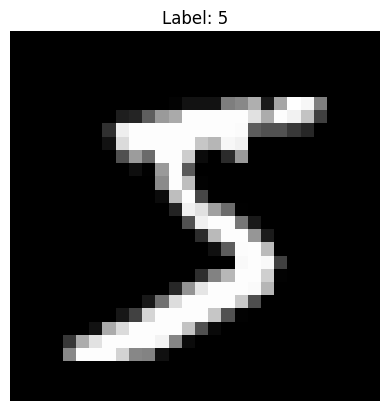

In [17]:
# Display one image

plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

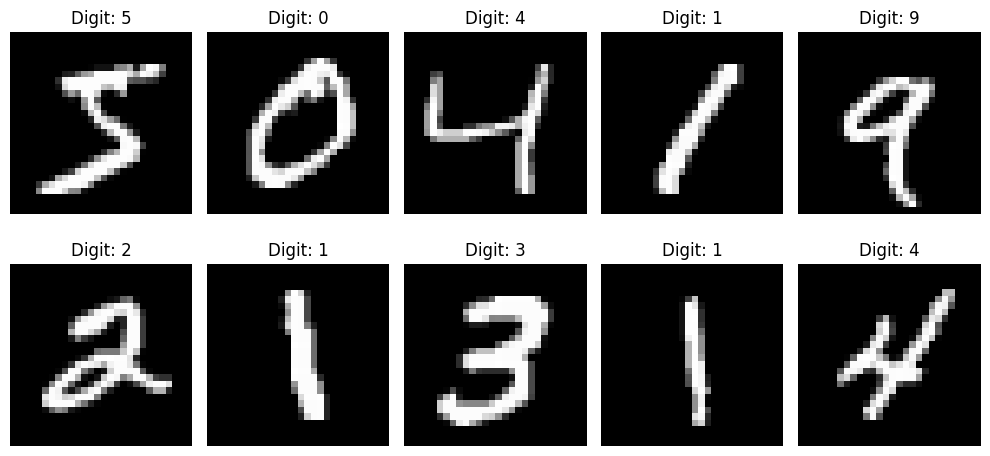

In [18]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Normalize pixel values from 0-255 to 0-1

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [20]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9249 - loss: 0.2524 - val_accuracy: 0.9655 - val_loss: 0.1158
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9668 - loss: 0.1092 - val_accuracy: 0.9713 - val_loss: 0.1016
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9763 - loss: 0.0770 - val_accuracy: 0.9723 - val_loss: 0.0903
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9819 - loss: 0.0566 - val_accuracy: 0.9747 - val_loss: 0.0864
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9857 - loss: 0.0438 - val_accuracy: 0.9728 - val_loss: 0.0939
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9889 - loss: 0.0356 - val_accuracy: 0.9757 - val_loss: 0.0918
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9898 - loss: 0.0307 - val_accuracy: 0.9823 - val_loss: 0.0816
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9920 - loss: 0.0251 - 

In [23]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.1044
Test Accuracy: 97.47%


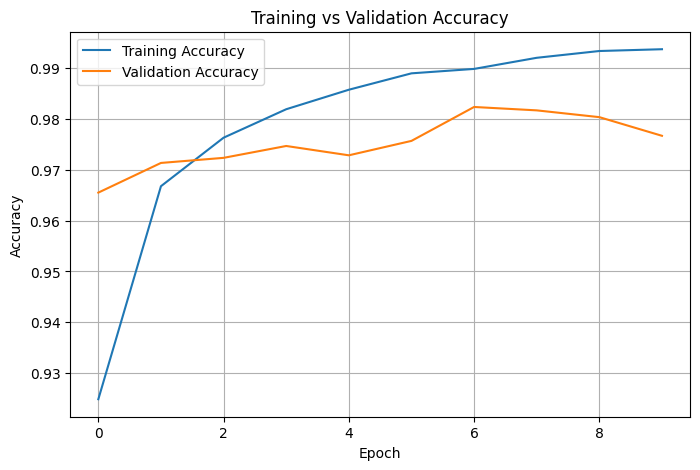

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

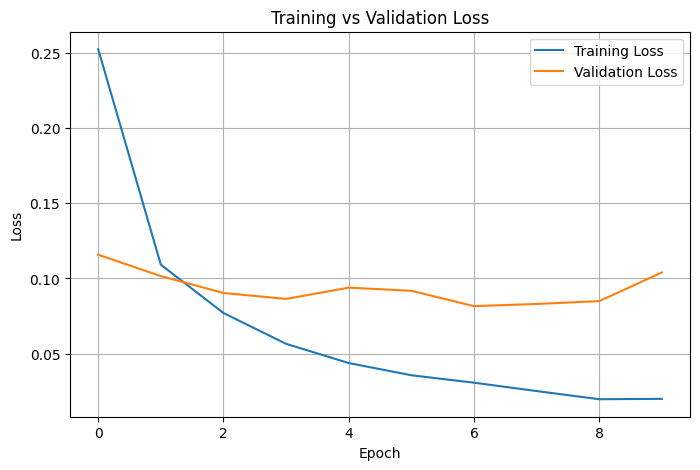

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

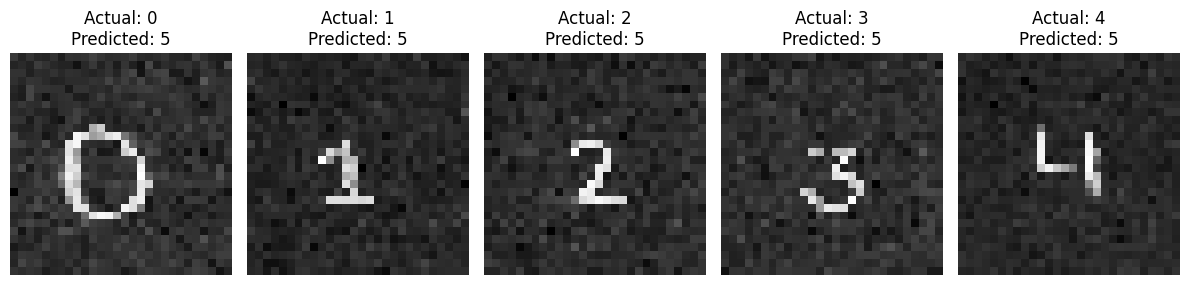

In [26]:
image_paths = [
    "digit_0.png",
    "digit_1.png",
    "digit_2.png",
    "digit_3.png",
    "digit_4.png"
]

actual_labels = [0, 1, 2, 3, 4]

predictions = []

plt.figure(figsize=(12, 4))

for i, path in enumerate(image_paths):

    # Load image
    img = load_img(
        path,
        color_mode="grayscale",
        target_size=(28, 28)
    )

    # Convert to array
    img_array = img_to_array(img)

    # Normalize
    img_array = img_array / 255.0

    # Invert image if required
    img_array = 1 - img_array

    # Predict
    prediction = model.predict(
        np.expand_dims(img_array, axis=0),
        verbose=0
    )

    predicted_label = np.argmax(prediction)
    predictions.append(predicted_label)

    # Display
    plt.subplot(1, 5, i + 1)
    plt.imshow(img_array.squeeze(), cmap="gray")
    plt.title(
        f"Actual: {actual_labels[i]}\n"
        f"Predicted: {predicted_label}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
print("Actual vs Predicted")

for i in range(5):
    print(
        f"Image {i+1}: "
        f"Actual = {actual_labels[i]}, "
        f"Predicted = {predictions[i]}"
    )

Actual vs Predicted
Image 1: Actual = 0, Predicted = 5
Image 2: Actual = 1, Predicted = 5
Image 3: Actual = 2, Predicted = 5
Image 4: Actual = 3, Predicted = 5
Image 5: Actual = 4, Predicted = 5


In [28]:
experiment_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

experiment_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
experiment_history = experiment_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8916 - loss: 0.3596 - val_accuracy: 0.9668 - val_loss: 0.1173
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9481 - loss: 0.1722 - val_accuracy: 0.9765 - val_loss: 0.0838
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9596 - loss: 0.1324 - val_accuracy: 0.9777 - val_loss: 0.0780
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9659 - loss: 0.1126 - val_accuracy: 0.9782 - val_loss: 0.0817
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9695 - loss: 0.0974 - val_accuracy: 0.9802 - val_loss: 0.0751
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9727 - loss: 0.0895 - val_accuracy: 0.9790 - val_loss: 0.0737
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9738 - loss: 0.0814 - val_accuracy: 0.9800 - val_loss: 0.0651
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9769 - loss: 0.0756 

In [30]:
experiment_loss, experiment_accuracy = experiment_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Original Model Accuracy: {test_accuracy * 100:.2f}%")
print(f"Dropout Model Accuracy: {experiment_accuracy * 100:.2f}%")

Original Model Accuracy: 97.47%
Dropout Model Accuracy: 98.08%


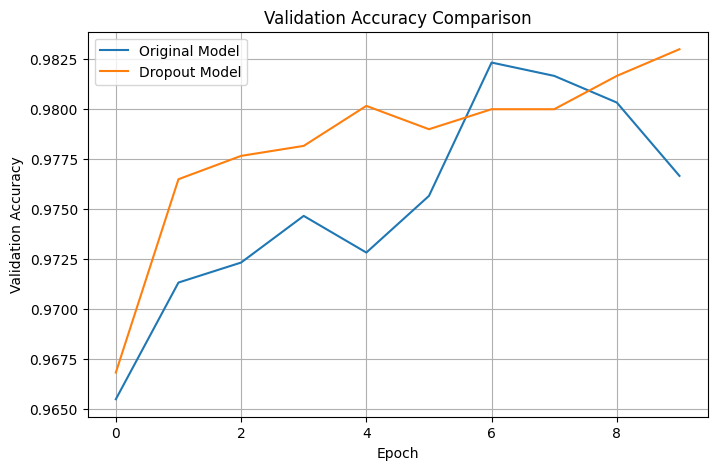

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    label="Original Model"
)

plt.plot(
    experiment_history.history["val_accuracy"],
    label="Dropout Model"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Conclusion

In this assignment, a simple neural network was developed using TensorFlow/Keras
to classify handwritten digits from the MNIST dataset.

The MNIST dataset was explored and the images were normalized before training.
The neural network consisted of a Flatten layer, two fully connected hidden
layers with ReLU activation, and an output layer with Softmax activation.

The model was trained using the Adam optimizer and sparse categorical
cross-entropy loss. Its performance was evaluated using the MNIST test dataset,
and training and validation accuracy and loss were visualized.

The trained model was also tested on five handwritten images, where the actual
and predicted labels were compared.

As an experiment, dropout layers with a rate of 0.2 were added to the neural
network. The original and dropout models were compared using test accuracy and
validation performance. This experiment demonstrated how changing the network
architecture can affect model performance and generalization.